In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from xgcm import Grid
import numpy as np

In [36]:
data_dir = '/scratch/pp2681/mom6/OM4_SIS2/unparameterized/output/'
files_OM4 = data_dir + '19*.ocean_daily_*.nc'
ds_daily = xr.open_mfdataset(files_OM4)

files_surf_OM4 = data_dir + '19*.ocean_month_0*.nc'
ds_month = xr.open_mfdataset(files_surf_OM4)

files_surf_OM4 = data_dir + '19*.ocean_month_z_0*.nc'
ds_month_z = xr.open_mfdataset(files_surf_OM4)

In [37]:
data_dir = '/home/db194/scratch_db194/OM4_jun_2025/test_my_ANN_long/'
files_OM4 = data_dir + '1977*.ocean_daily_*.nc'
ds_daily_ann = xr.open_mfdataset(files_OM4)

files_surf_OM4 = data_dir + '1977*.ocean_month_0*.nc'
ds_month_ann = xr.open_mfdataset(files_surf_OM4)

files_surf_OM4 = data_dir + '1977*.ocean_month_z_0*.nc'
ds_month_z_ann = xr.open_mfdataset(files_surf_OM4)


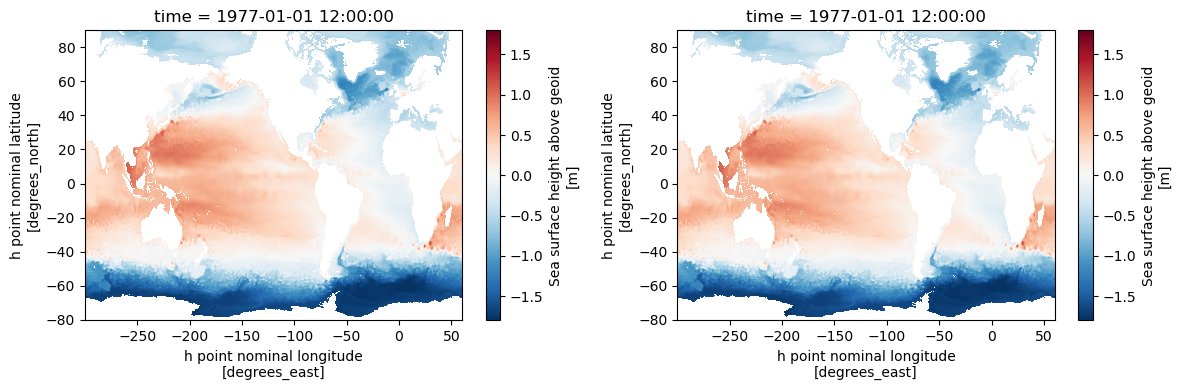

In [38]:
plt.figure(figsize=(12, 4))

idT = 0

plt.subplot(121)
ds_daily.zos.isel(time=idT).plot()

plt.subplot(122)    
ds_daily_ann.zos.isel(time=idT).plot()

plt.tight_layout()

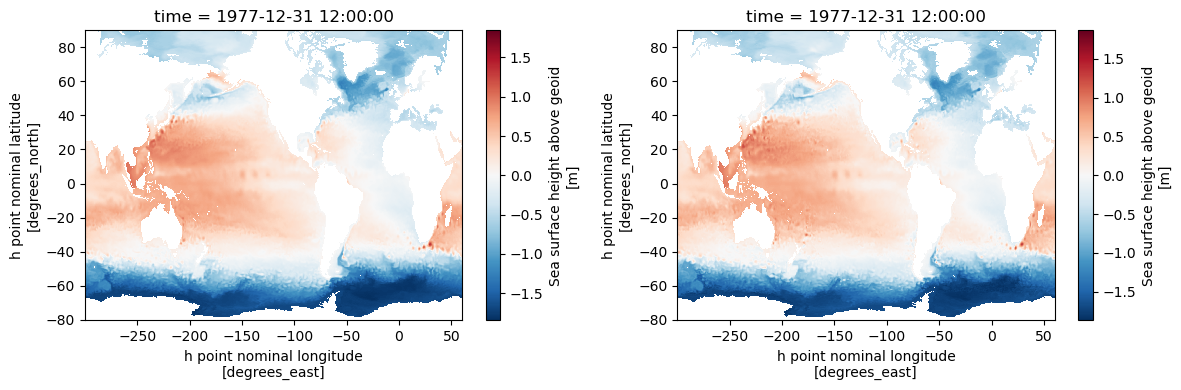

In [39]:
plt.figure(figsize=(12, 4))

idT = 364

plt.subplot(121)
ds_daily.zos.isel(time=idT).plot()

plt.subplot(122)    
ds_daily_ann.zos.isel(time=idT).plot()

plt.tight_layout()

In [40]:
def KE(ds):
    grid = Grid(ds, coords={'X': {'center': 'xh', 'right': 'xq'},
                        'Y': {'center': 'yh', 'right': 'yq'}, }, periodic='X')
    return grid.interp(ds.ssu, 'X')**2 + grid.interp(ds.ssv, 'Y', boundary='extend')**2

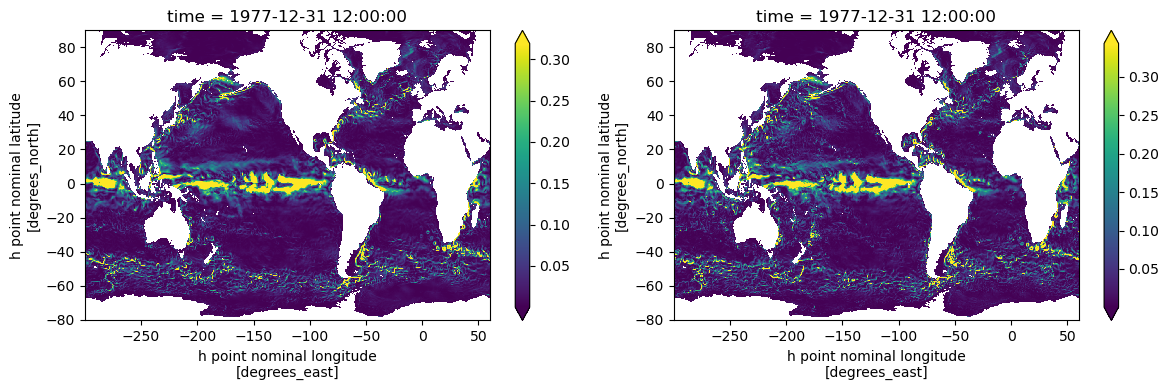

In [41]:
plt.figure(figsize=(12, 4))

idT = 364

plt.subplot(121)
KE(ds_daily).isel(time=idT).plot(robust=True)

plt.subplot(122)    
KE(ds_daily_ann).isel(time=idT).plot(robust=True)

plt.tight_layout()

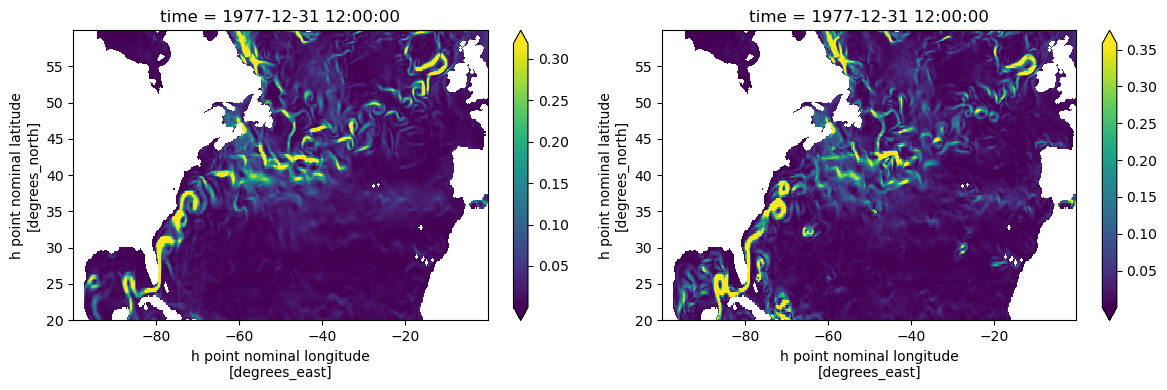

In [42]:
plt.figure(figsize=(12, 4))

idT = 364

plt.subplot(121)
KE(ds_daily).isel(time=idT).sel(xh=slice(-100,0), yh=slice(20,60)).plot(robust=True)

plt.subplot(122)    
KE(ds_daily_ann).isel(time=idT).sel(xh=slice(-100,0), yh=slice(20,60)).plot(robust=True)

plt.tight_layout()

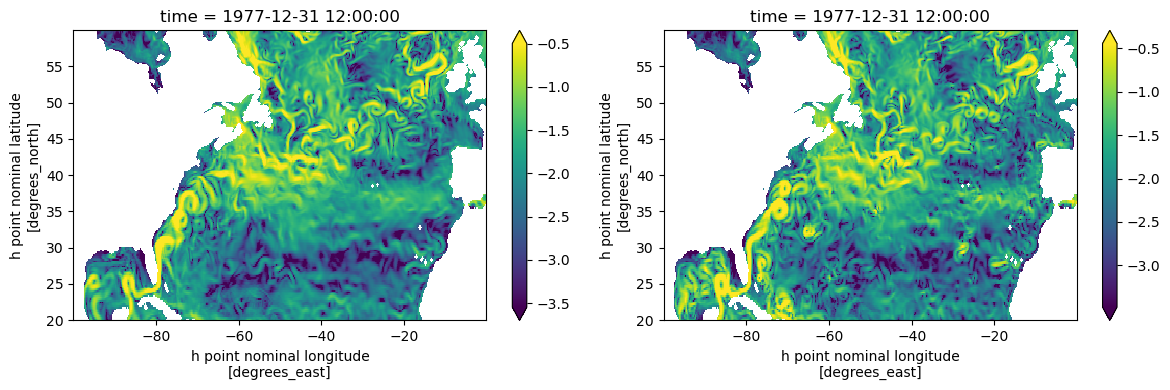

In [43]:
plt.figure(figsize=(12, 4))

idT = 364

plt.subplot(121)
np.log10(KE(ds_daily)).isel(time=idT).sel(xh=slice(-100,0), yh=slice(20,60)).plot(robust=True)

plt.subplot(122)    
np.log10(KE(ds_daily_ann)).isel(time=idT).sel(xh=slice(-100,0), yh=slice(20,60)).plot(robust=True)

plt.tight_layout()

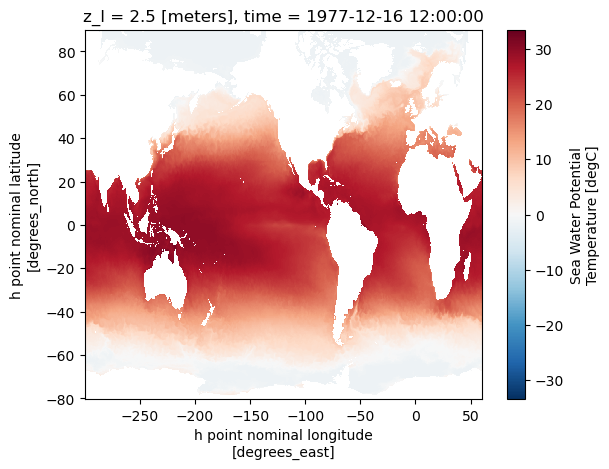

In [51]:
ds_month_z_ann.thetao.isel(time=-1, z_l=0).plot()

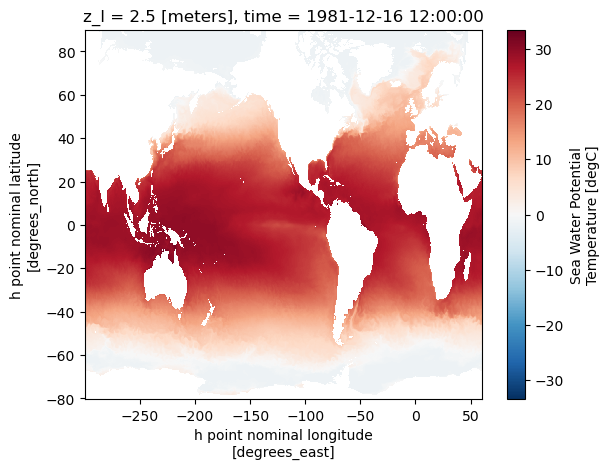

In [52]:
ds_month_z.thetao.isel(time=-1, z_l=0).plot()

/ext3/miniforge/lib/python3.10/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


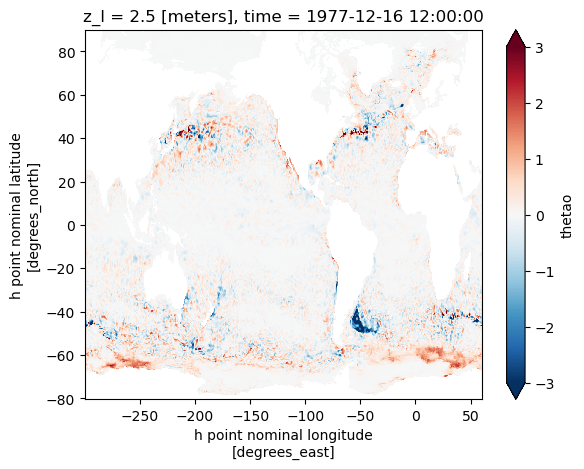

In [54]:


(ds_month_z_ann.thetao - ds_month_z.thetao).isel(time=-1, z_l=0).plot(vmin=-3)

/ext3/miniforge/lib/python3.10/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


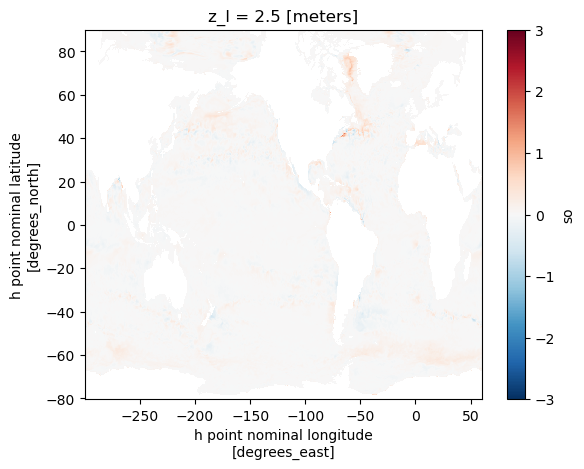

In [55]:


(ds_month_z_ann.so - ds_month_z.so).isel(time=slice(6,-1), z_l=0).mean('time').plot(vmin=-3)